# Laboratorio 7. Spark MLlib

Universidad del Valle de Guatemala

Data Science

Nina Najera, 231088

24 de septiembre de 2026

## Propósito

Se estudian los salarios y perfiles de los registros de personas asalariadas de la ENEIC de 2025. Se usan las cuatro bases de Personas de 2025 y se prepara por separado la de 2026. Esta última no se usa para explorar salarios ni elegir los grupos.

El salario corresponde a P05D01: pago mensual sin descuentos de la ocupación principal, en quetzales. No incluye automáticamente otros ingresos. Las estadísticas y los grupos no usan ponderaciones, por lo que describen los registros analizados y no son estimaciones oficiales de toda Guatemala.

## Entorno y procedimiento

Se utiliza Spark 3.5.1 y Java 17 en Docker. Las funciones están en src/laboratorio.py para mantener el notebook corto. Excel se lee con openpyxl, un archivo a la vez; luego la preparación, las estadísticas y KMeans se realizan en Spark. A pandas solo pasan tablas resumidas. Las bases y los diccionarios se obtienen del INE; sus enlaces y huellas SHA-256 están en data/sources.json.

Fuente: https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))
from src.laboratorio import session, prepare, descriptive, correlations, clusters
spark = session()
print("Spark:", spark.version, "| Java:", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 23:06:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1 | Java: 17.0.20.1


## 1. Carga, armonización y calidad

Se seleccionan las mismas 14 variables originales y se asignan tipos explícitos. Se conservan ANIO y TRIMESTRE, pero el año y trimestre calendario se asignan a partir del archivo. No se resta uno a TRIMESTRE. Los cuatro archivos de 2025 se unen mediante unionByName.

Los filtros se aplican siempre en este orden: edad, condición de ocupado, categoría asalariada, salario positivo, años de antigüedad, meses de antigüedad, antigüedad total y horas. Los valores numéricos deben ser finitos. Los meses deben ser enteros entre 0 y 11, y la antigüedad se calcula como años más meses divididos entre 12. No se imputa el salario ni se recortan valores extremos.

Los códigos se revisan contra el diccionario de cada período. Los ausentes o inválidos se representan como DESCONOCIDO. El nivel educativo 0 se conserva porque significa ninguno.

La unicidad se revisa antes de los filtros usando período, hogar y persona. Se compara una huella de todas las columnas originales para distinguir repeticiones exactas de conflictos. Si aparecen claves duplicadas, la ejecución se detiene para investigarlas; no se eliminan automáticamente.

In [2]:
datos, calidad = prepare(spark)
datos.printSchema()
datos.orderBy("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA").show(5, truncate=False)
for nombre, tabla in calidad.items():
    print(nombre)
    display(tabla)

Preparando 2025T1


Preparando 2025T2


Preparando 2025T3


Preparando 2025T4


Preparando 2026T1


...

,periodo,claves_duplicadas,exactas,en_conflicto,claves_nulas
0,2025T1,0,0,0,0
1,2025T2,0,0,0,0
2,2025T3,0,0,0,0
3,2025T4,0,0,0,0
4,2026T1,0,0,0,0


codigos_desconocidos


,periodo,variable,desconocidos_antes_filtros
0,2025T1,P03A03A,6928
1,2025T1,P05C16,29315
2,2025T1,DOMINIO,0
3,2025T2,P03A03A,6678
4,2025T2,P05C16,28824
5,2025T2,DOMINIO,0
6,2025T3,P03A03A,6548
7,2025T3,P05C16,29210
8,2025T3,DOMINIO,0
9,2025T4,P03A03A,6190


trimestres_originales


,periodo,TRIMESTRE,n
0,2025T1,2.000,51588
1,2025T2,3.000,50992
2,2025T2,2.000,175
3,2025T3,4.000,51583
4,2025T4,5.000,49338
5,2026T1,6.000,49843


### Resultados de calidad

Los cuatro archivos de 2025 suman 203,676 registros originales. Después de aplicar los filtros quedan 53,025 observaciones, equivalentes al 26.03% de esas filas. El archivo de 2026 conserva 13,258 registros elegibles y queda guardado por separado.

No se encontraron claves duplicadas ni identificadores ausentes dentro de cada período. Esto no significa que las personas sean diferentes entre trimestres. La auditoría de TRIMESTRE conserva los valores 2, 3, 4, 5 y 6 según el archivo. En II de 2025 se mantienen los 175 registros cuyo TRIMESTRE original es 2; todos pertenecen al archivo 2025T2.

La tabla de exclusiones permite seguir cuántos registros se pierden en cada regla. En estos archivos, las pérdidas ocurren por edad, condición de ocupado y categoría ocupacional. Después de seleccionar asalariados, las reglas de salario, antigüedad y horas no excluyen registros adicionales. Las exclusiones de un paso se cuentan sobre quienes superaron los pasos anteriores, por lo que no se suman causas superpuestas. Los faltantes del salario antes de filtrar incluyen a personas fuera de la población asalariada y no deben interpretarse todos como falta de respuesta entre asalariados.

### Interpretación de la preparación

IV de 2025 tiene 302 columnas, mientras los demás archivos tienen 270. Además, las posiciones cambian: por ejemplo, el nivel educativo aparece en la posición 29 en IV y en la 33 en I. Apilar por posición mezclaría variables distintas. Seleccionar por nombre y usar unionByName evita ese problema.

Un dato puede estar vacío porque la pregunta no corresponde a esa persona, por ejemplo una pregunta de salario para alguien que no es asalariado. Una respuesta no registrada ocurre cuando sí correspondía preguntar, pero no quedó un valor. Una celda vacía por sí sola no permite distinguir ambos casos; se necesita revisar la ruta del cuestionario. La tabla de faltantes cuenta valores vacíos antes de filtrar, sin suponer que todos son errores.

Una persona observada en dos períodos aporta dos observaciones diferentes. El período forma parte de la clave y no se debe eliminar una de esas observaciones solo por repetir hogar y persona. Por esa misma razón, la suma de filas no equivale necesariamente al número de personas distintas.

La base filtrada no representa a todos los trabajadores: incluye solo asalariados de 15 años o más, con salario positivo y datos numéricos válidos. Se excluyen, entre otros, trabajadores por cuenta propia y personas sin salario registrado. FACTOR se conserva porque serviría para ponderar un análisis poblacional junto con el diseño de la encuesta, pero aquí no se usa.

Los datos preparados se guardan por separado en processed/parquet/personas_2025 y processed/parquet/personas_2026.

## 2. Estadística descriptiva

Las estadísticas se calculan sobre todos los registros elegibles de 2025. La desviación estándar es muestral y los percentiles se calculan con percentile de Spark. El histograma también usa todos los registros mediante conteos agregados; su eje salarial es logarítmico para poder ver salarios pequeños y grandes. El salario original permanece en quetzales.

descriptivos


,variable,n,media,desviacion,minimo,maximo,p25,mediana,p75,p95
0,salario_mensual,53025,"3,421.684","2,902.109",1.000,"99,000.000","1,800.000","3,000.000","4,000.000","8,000.000"
1,edad,53025,35.188,13.521,15.000,89.000,24.000,33.000,44.000,61.000
2,antiguedad,53025,5.559,7.831,0.000,70.000,0.500,2.000,7.000,22.000
3,horas_semanales,53025,46.307,18.630,1.000,126.000,40.000,45.000,55.000,80.000


nivel_educativo


,nivel_educativo,n,mediana,etiqueta
0,0,3995,"1,500.000",Ninguno
1,1,459,"2,160.000",Preprimaria
2,2,15822,"2,200.000",Primaria
3,3,8249,"2,800.000",Básico
4,4,16851,"3,600.000",Diversificado
5,5,6818,"5,000.000",Superior
6,6,771,"10,000.000",Maestría
7,7,60,"12,000.000",Doctorado


categoria_ocupacional


,categoria_ocupacional,n,mediana,etiqueta
0,1,6575,"5,000.000",Gobierno
1,2,28702,"3,567.500",Empresa privada
2,3,13842,"1,800.000",Jornalero o peón
3,4,3906,"1,000.000",Servicio doméstico


dominio


,dominio,n,mediana,etiqueta
0,1,22072,"3,700.000",Urbano metropolitano
1,2,20146,"2,880.000",Resto urbano
2,3,10807,"2,000.000",Rural nacional


trimestres


,periodo_archivo,n,mediana
0,2025T1,13419,"3,000.000"
1,2025T2,13492,"3,000.000"
2,2025T3,13450,"3,200.000"
3,2025T4,12664,"3,200.000"


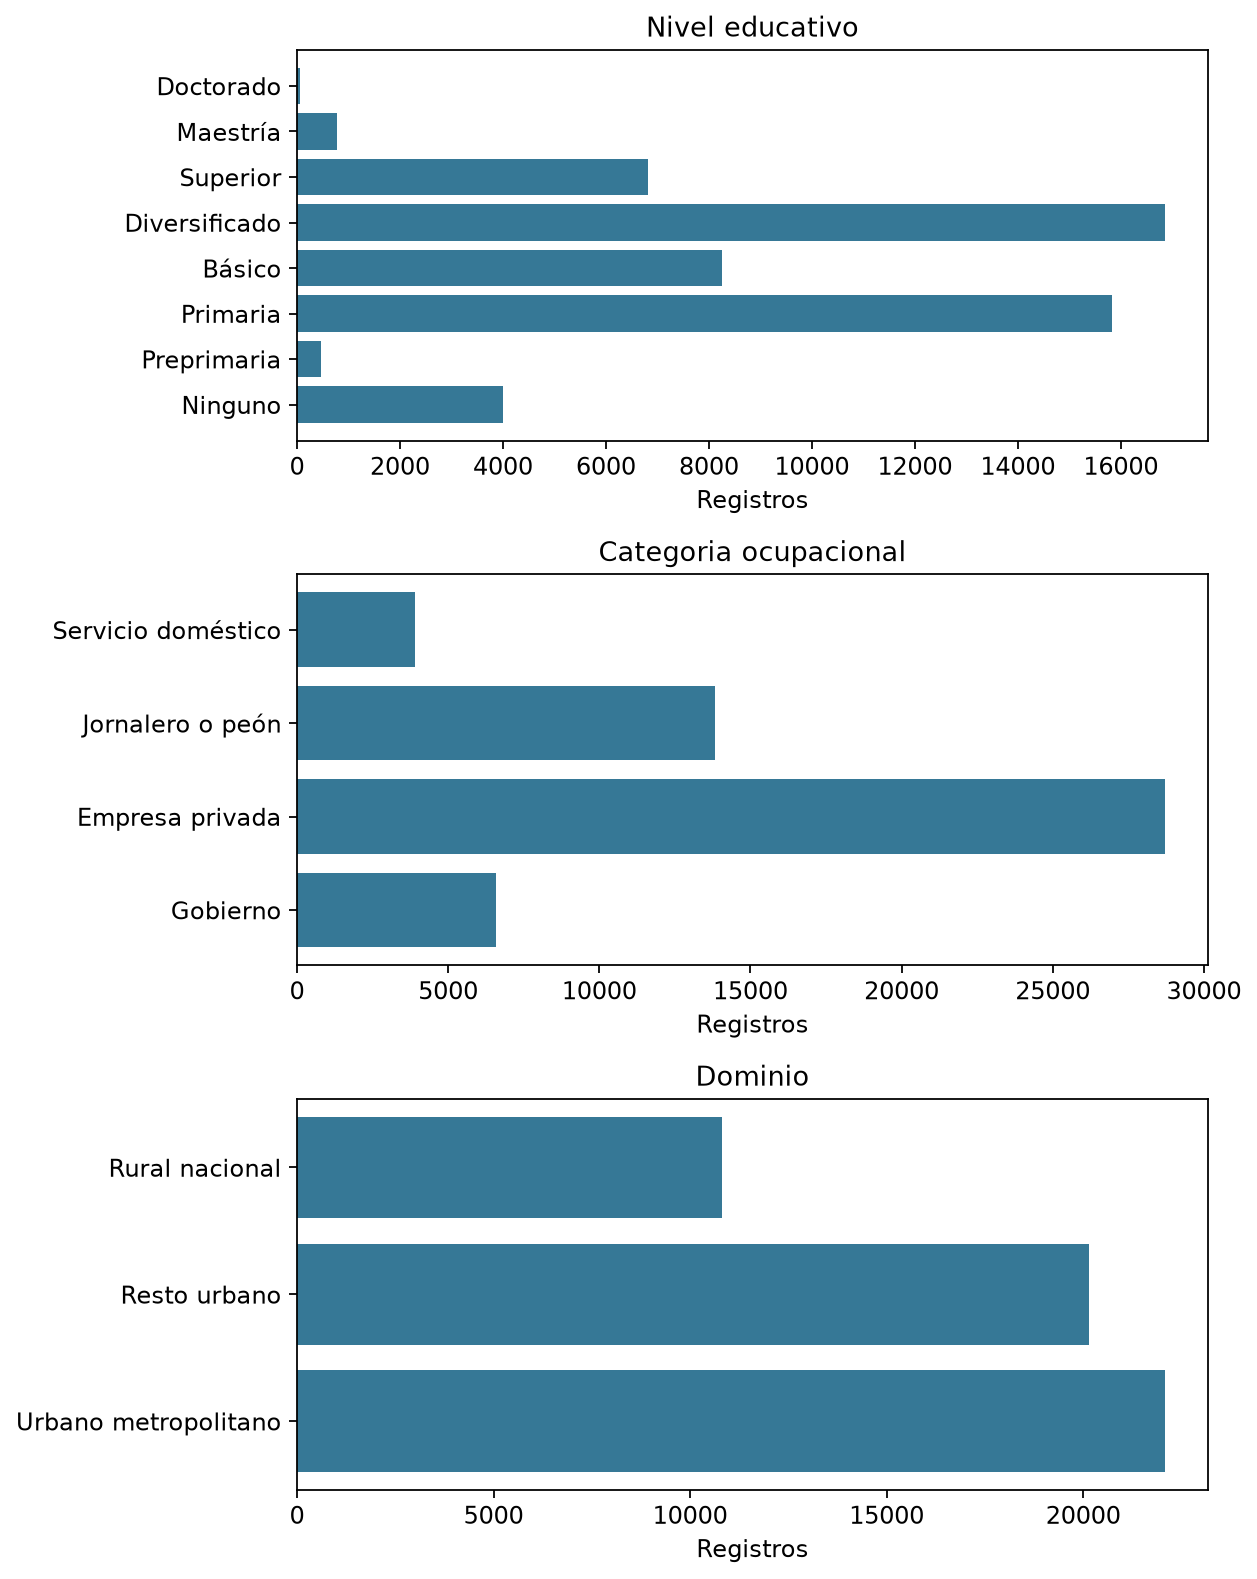

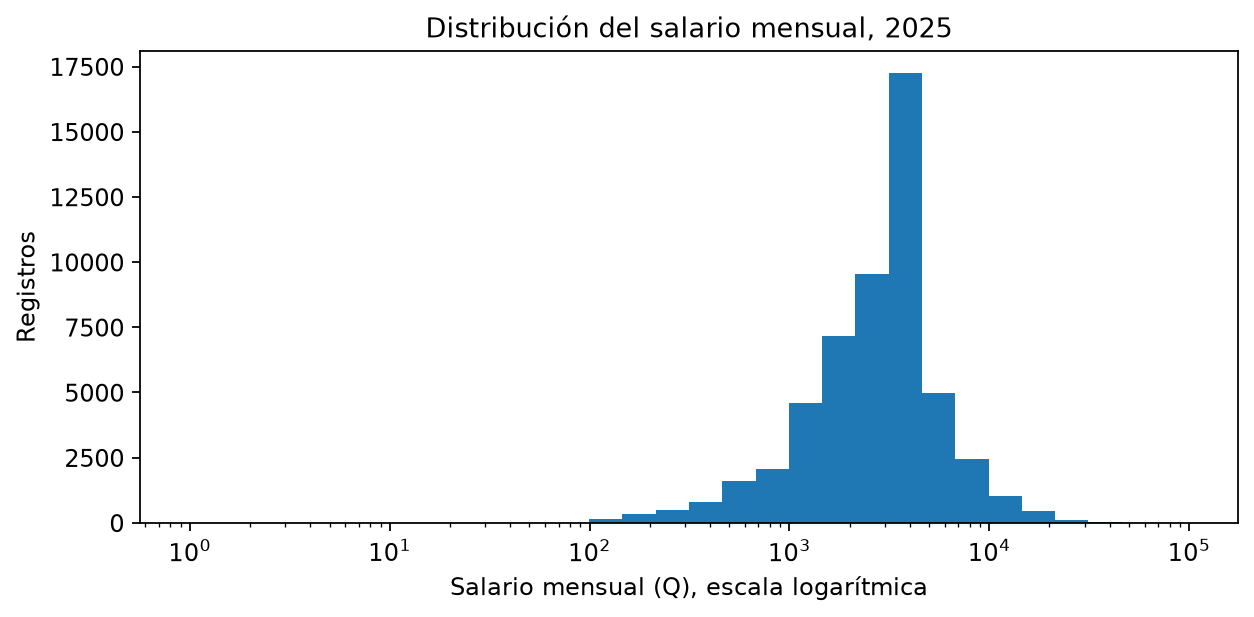

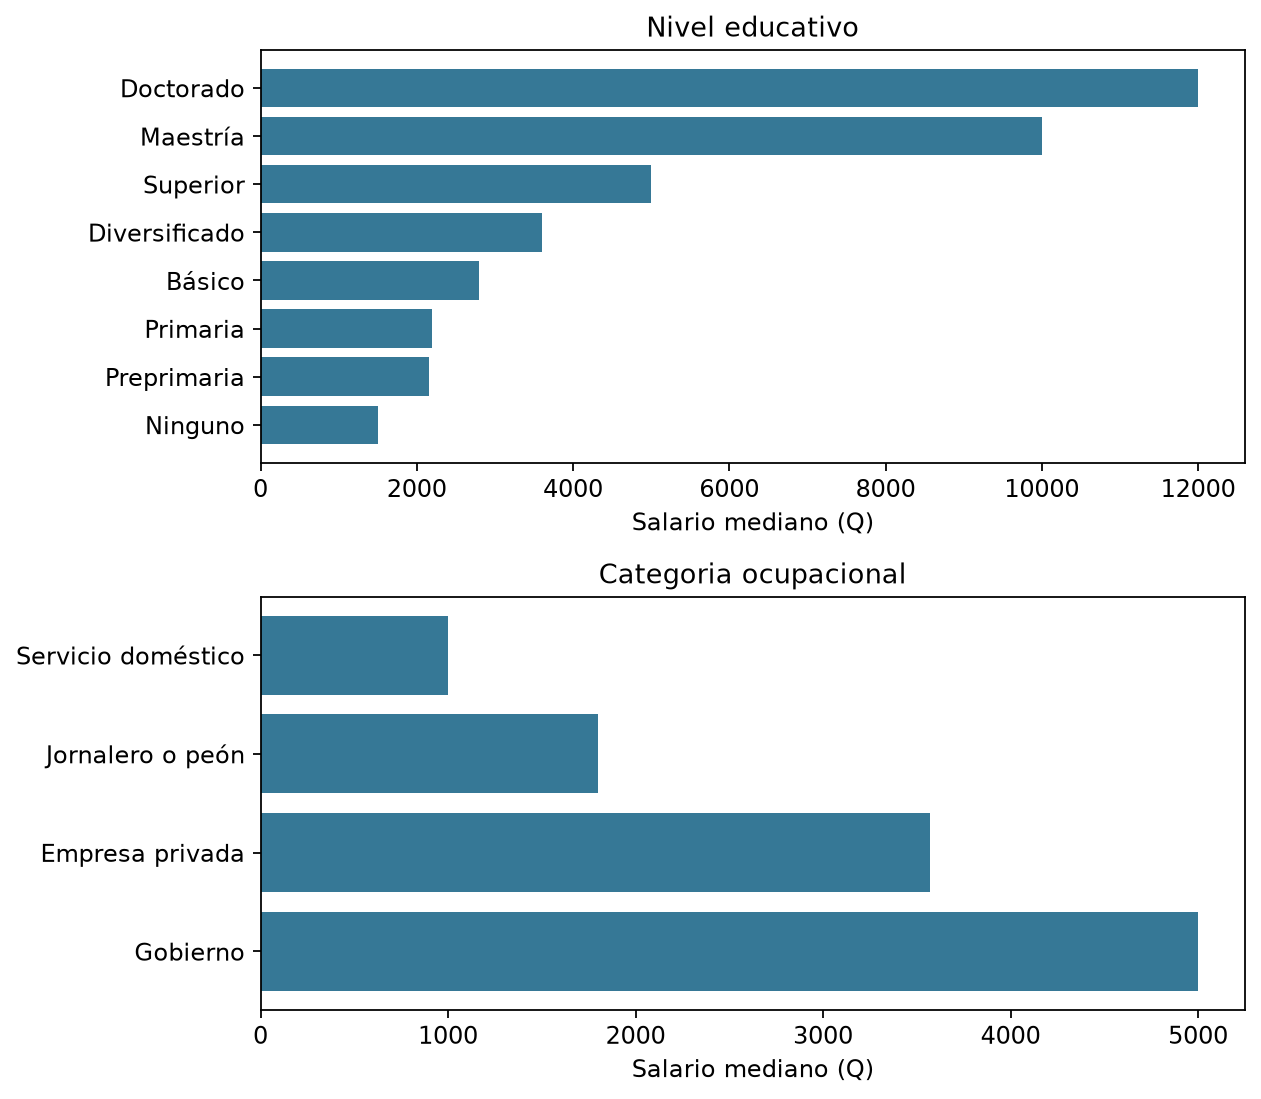

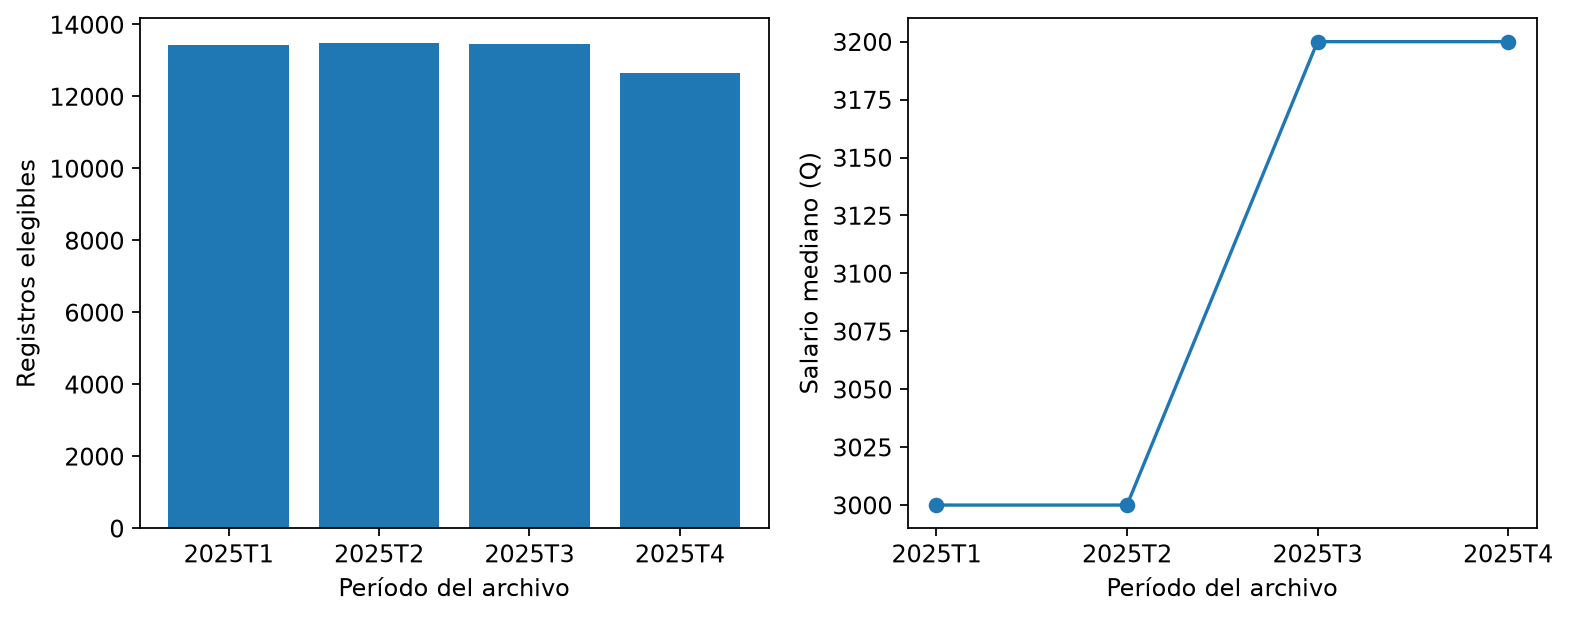

In [3]:
resumen = descriptive(datos)
for nombre, tabla in resumen.items():
    print(nombre)
    display(tabla)
for nombre in ["distribucion_categorias.png", "distribucion_salarios.png", "salario_por_grupo.png", "comparacion_trimestres.png"]:
    display(Image(filename=str(root / "processed/images" / nombre)))

### Interpretación de las distribuciones

En categoría ocupacional, el grupo con más registros es Empresa privada, con 28,702 observaciones (54.13%). En nivel educativo, el grupo con más registros es Diversificado, con 16,851 observaciones (31.78%). En dominio, el grupo con más registros es Urbano metropolitano, con 22,072 observaciones (41.63%). Las barras describen la composición de la base analizada, sin ponderar por el factor de expansión.

El salario tiene una distribución asimétrica hacia la derecha. Su media es Q3,421.68 y su mediana es Q3,000.00; la diferencia es Q421.68. Los valores altos elevan la media. La mitad de las observaciones recibe hasta la mediana. El percentil 95 es Q8,000.00 y el máximo es Q99,000.00, por lo que hay una cola alta que no se elimina.

En educación, las medianas por nivel son: Ninguno: Q1,500.00 (n=3,995), Preprimaria: Q2,160.00 (n=459), Primaria: Q2,200.00 (n=15,822), Básico: Q2,800.00 (n=8,249), Diversificado: Q3,600.00 (n=16,851), Superior: Q5,000.00 (n=6,818), Maestría: Q10,000.00 (n=771), Doctorado: Q12,000.00 (n=60). En categorías ocupacionales son: Gobierno: Q5,000.00, Empresa privada: Q3,567.50, Jornalero o peón: Q1,800.00, Servicio doméstico: Q1,000.00. Las medianas suben al pasar a niveles educativos más altos; sin embargo, doctorado tiene solo 60 registros y su mediana requiere cautela. El salario mediano del gobierno (Q5,000) es cinco veces el del servicio domástico (Q1,000), sin ajustar por otras características. Estas diferencias son asociaciones observadas; no prueban un efecto causal de la educación o del tipo de empleo. Los grupos pequeños requieren especial cuidado al comparar.

Por trimestre, el tamaño y salario mediano son: 2025T1: 13,419 registros y Q3,000.00; 2025T2: 13,492 registros y Q3,000.00; 2025T3: 13,450 registros y Q3,200.00; 2025T4: 12,664 registros y Q3,200.00. La mediana sube de Q3,000 a Q3,200 entre el segundo y tercer trimestre y se mantiene en el cuarto, mientras la cantidad de registros baja en el cuarto trimestre. Los cambios pueden reflejar diferencias en la composición y en la rotación de la muestra, además de cambios salariales. No equivalen al cambio del salario de una misma persona.

## 3. Relaciones entre variables numéricas

Se usa VectorAssembler y Correlation.corr con el método de Pearson sobre todos los registros elegibles de 2025. Los valores cercanos a 1 indican asociación lineal positiva y los cercanos a 0 indican poca asociación lineal. La correlación no demuestra que una variable cause cambios en otra.

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


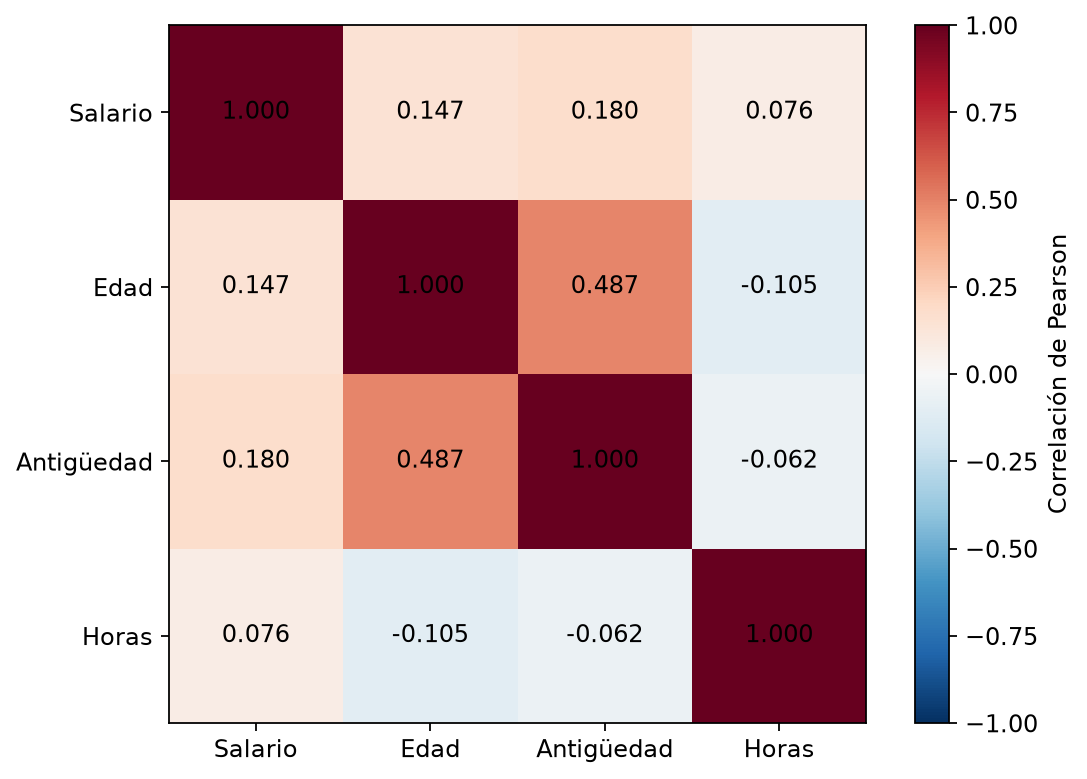

In [4]:
matriz = correlations(datos)
display(matriz)
display(Image(filename=str(root / "processed/images/correlaciones.png")))

### Interpretación de las correlaciones

La mayor asociación lineal con el salario entre los tres predictores numéricos es la de antiguedad, con r = 0.180. Las otras correlaciones del salario son: edad: 0.147, horas semanales: 0.076.

La correlación entre edad y antigüedad es 0.487. El signo positivo indica que las personas de mayor edad tienden a acumular más tiempo en el empleo, aunque no ocurre igual en todos los casos. Las tres asociaciones con el salario son positivas pero débiles: ninguna llega a 0.20. Por separado, estas variables tienen poca relación lineal con el salario. Pearson resume asociaciones lineales; no explica por sí solo el salario y es sensible a valores extremos. La educación, la categoría y el dominio tampoco están incluidos en esta matriz numérica.

## 4. Segmentación con KMeans

Se forman grupos con edad, antigüedad y horas semanales. No se incluye el salario para que los perfiles se definan por características laborales y personales y no principalmente por cuánto ganan. Incluirlo podría ser útil para segmentar ingresos, pero sus valores extremos podrían dominar las distancias. El salario mediano se compara después de formar los grupos.

StandardScaler centra cada variable y la divide por su desviación estándar. Así se evita que las distintas unidades dominen el cálculo. Se prueban K igual a 2, 3, 4 y 5, con semilla 231088. Se elige el mayor silhouette; en caso de empate, el menor K. El indicador usa distancia euclidiana al cuadrado y se calcula sobre toda la base de 2025. Las etiquetas numéricas de los grupos son identificadores, no un orden de calidad.

,k,silhouette,costo
0,2,0.554,"106,717.388"
1,3,0.443,"84,468.146"
2,4,0.476,"64,438.201"
3,5,0.391,"58,555.065"


K seleccionado: 2


,prediction,n,edad,antiguedad,horas_semanales,salario_mediano
0,0,38421,29.071,2.424,48.212,"3,000.000"
1,1,14604,51.279,13.805,41.296,"3,466.000"


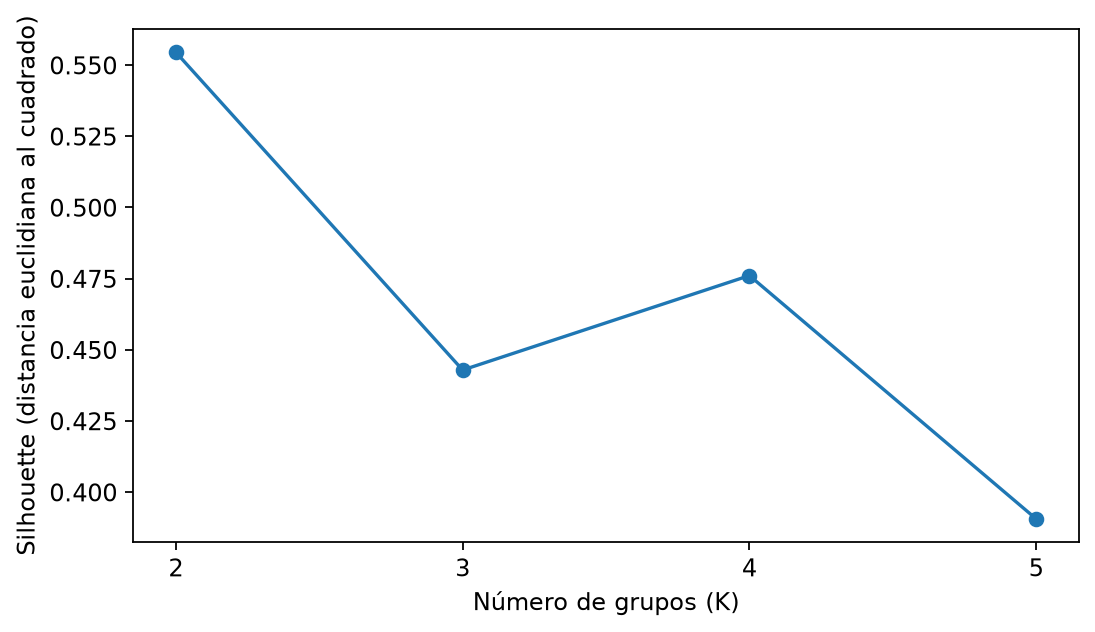

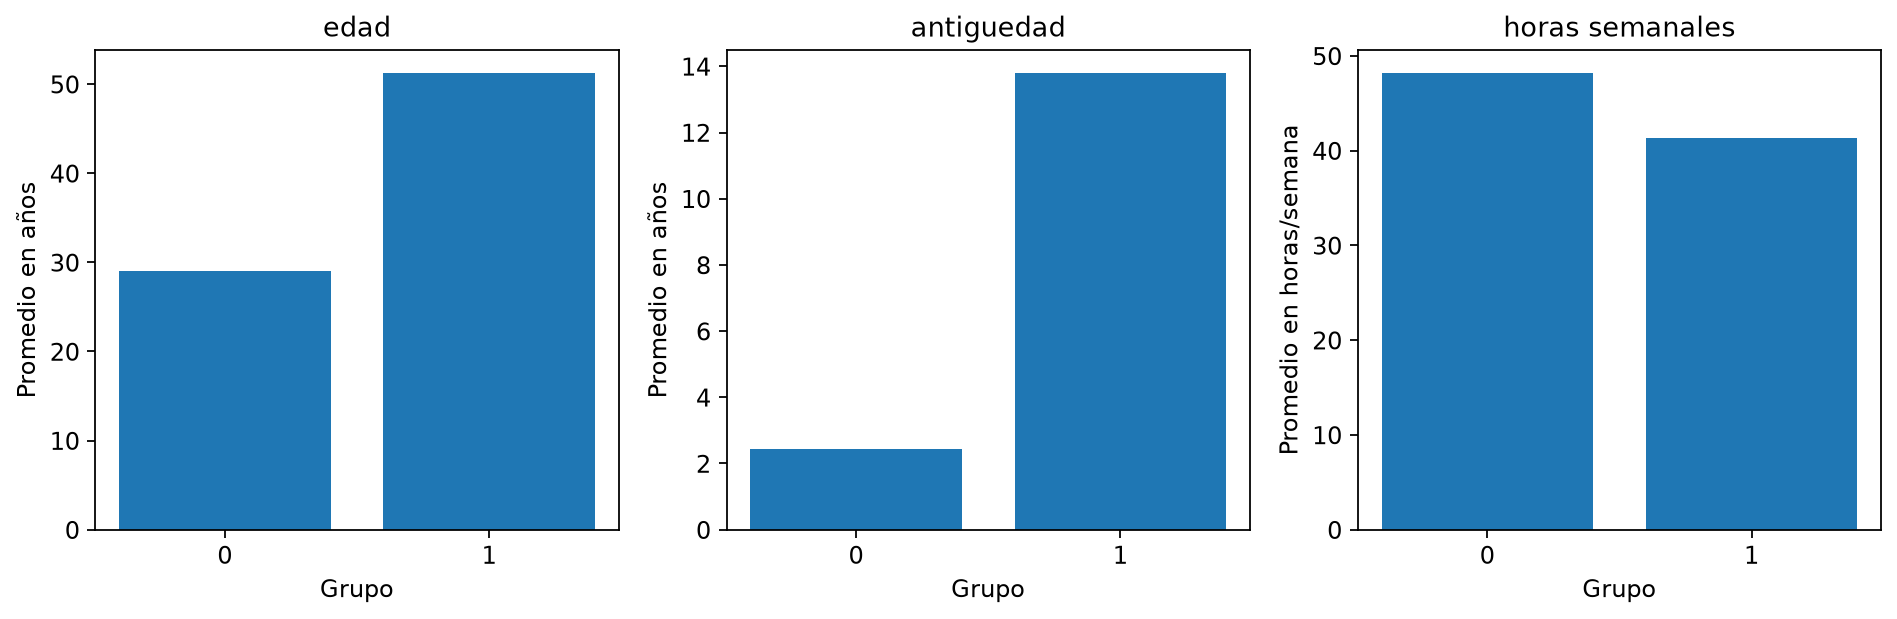

In [5]:
seleccion, perfiles, mejor_k = clusters(datos)
display(seleccion)
print("K seleccionado:", mejor_k)
display(perfiles)
for nombre in ["seleccion_k.png", "perfiles_clusters.png"]:
    display(Image(filename=str(root / "processed/images" / nombre)))

### Interpretación de los grupos

Se selecciona K = 2 porque obtuvo el mayor silhouette, 0.5545, entre las cuatro opciones probadas. El criterio compara qué tan cerca están los registros de su propio grupo frente a los demás; un valor mayor es preferible dentro de esta comparación. No prueba que esta sea la única segmentación posible.


Grupo 0: menor edad, menor antigüedad y jornadas más largas. Contiene 38,421 registros (72.46%). Sus promedios son 29.07 años de edad, 2.42 años de antigüedad y 48.21 horas semanales. Su salario mediano es Q3,000.00.


Grupo 1: mayor edad, mayor antigüedad y jornadas más cortas. Contiene 14,604 registros (27.54%). Sus promedios son 51.28 años de edad, 13.81 años de antigüedad y 41.30 horas semanales. Su salario mediano es Q3,466.00.

Las descripciones de mayor o menor edad, antigüedad y duración de jornada comparan los promedios del grupo con el promedio general de 2025. El salario mediano se calcula después de la segmentación y no interviene en las distancias. Una sola semilla da una ejecución reproducible, pero no demuestra estabilidad frente a otras inicializaciones. Los perfiles son una forma de resumir estos registros y no categorías oficiales de trabajadores.

## Límites del análisis

Las observaciones de varios períodos pueden corresponder a las mismas personas. Los tamaños de grupo cuentan registros, no personas distintas. La exclusión de datos incompletos puede cambiar la composición de los grupos. Los salarios extremos se conservan y pueden afectar la media y la correlación. KMeans crea grupos según las variables y las distancias elegidas; no demuestra que existan categorías naturales ni sirve para recomendar cuánto debería ganar una persona. Los resultados de 2026 permanecen reservados para la evaluación de modelos supervisados.

## Discusión de los resultados

La diferencia entre media y mediana muestra por qué no basta con resumir el salario usando un solo promedio. Las medianas por educación y categoría ayudan a comparar grupos sin que unos pocos salarios altos dominen tanto el resultado. Las correlaciones muestran asociaciones parciales, pero no permiten explicar por completo las diferencias salariales.

Los 2 grupos resumen combinaciones de edad, tiempo en el empleo y jornada. Comparar su salario mediano ayuda a describirlos, aunque el salario no se usó para crearlos. La base excluye registros sin información suficiente y no usa ponderaciones; por ello, las conclusiones se limitan a la población analítica definida y no deben presentarse como cifras oficiales para todo el país.

In [6]:
datos.unpersist()
spark.stop()